In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

In [2]:
col_names = ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv('../data/CMAPSSData/train_FD001.txt', sep=r'\s+', header=None, names=col_names)

In [3]:
print(train.shape)                          # (20631, 26)
print(train['unit'].nunique())              # 100

(20631, 26)
100


In [4]:
max_cycles = train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']
train = train.merge(max_cycles, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

In [5]:
sensor_cols = [c for c in train.columns if 'sensor' in c]
print(train[sensor_cols].std().sort_values())

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


Sensors 1, 5, 10, 16, 18, and 19 are the drop candidates for FD001.
Their standard deviation values say that these sensors are constant/effectively constant across every single row in the whole dataset: every engine, every cycle, same value.

Cross-reference:
sensor_1 is T2 (fan inlet temp)
sensor_5 is P2 (fan inlet pressure)
sensor_10 is epr (engine pressure ratio)
sensor_18/19 are demanded fan speeds.
That makes physical sense: since FD001 only has one operating condition (sea level, fixed throttle), the inlet conditions and demanded setpoints don't vary; only the engine's internal response to wear varies.

Sensors 3, 4, 9, and 14 are particularly really good candidates to keep. These large standard deviations suggest that these sensors are reacting the most to whatever is changing over an engine's life.

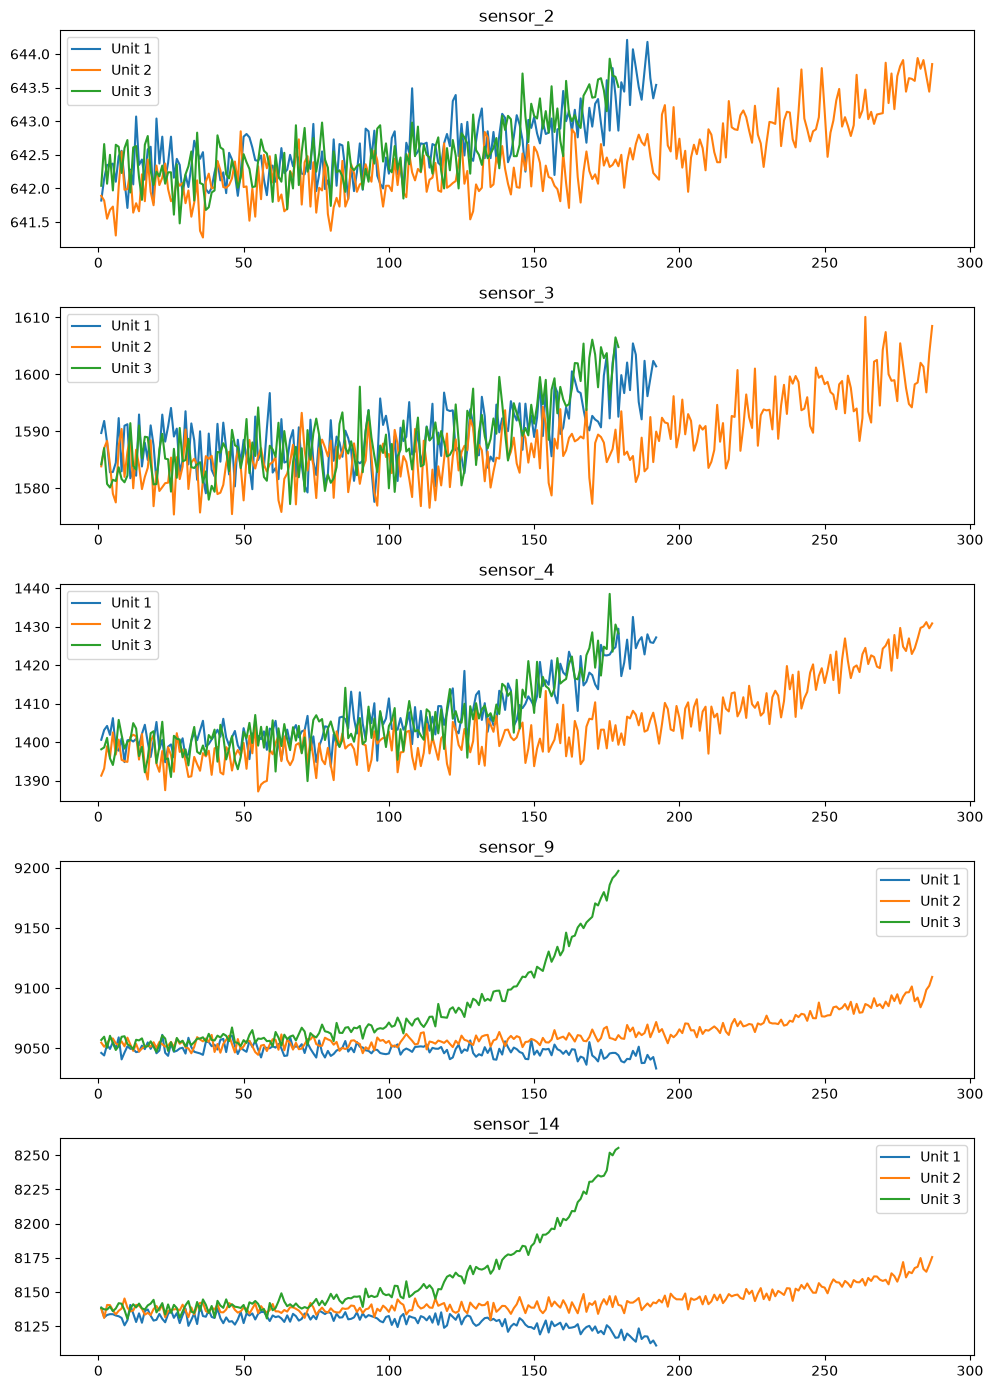

In [6]:
sample_units = [1, 2, 3]
informative_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_9', 'sensor_14']

fig, axes = plt.subplots(len(informative_sensors), 1, figsize=(10, 14))
for ax, sensor in zip(axes, informative_sensors):
    for unit in sample_units:
        d = train[train['unit'] == unit]
        ax.plot(d['cycle'], d[sensor], label=f'Unit {unit}')
    ax.set_title(sensor)
    ax.legend()
plt.tight_layout()
plt.show()

threshold = 30
train['fail_within_30'] = (train['RUL'] <= threshold).astype(int)
print(train['fail_within_30'].value_counts(normalize=True))

Sensors 1, 5, 6, 10, 16, 18, and 19 show zero or near-zero variance in FD001 and were dropped. This makes physical sense given FD001's single operating condition (sea-level, fixed throttle) — sensors tied to inlet/ambient conditions or commanded setpoints don't vary when the operating condition itself is fixed. The remaining 14 sensors capture the engine's actual response to internal wear.

**Rolling statistics**

In [7]:
window = 5  # look back 5 cycles

sensor_cols_to_use = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 
                       'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
                       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
                       'sensor_20', 'sensor_21']  # the 14 non-flat sensors

for sensor in sensor_cols_to_use:
    train[f'{sensor}_rollmean'] = (
        train.groupby('unit')[sensor]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )
    train[f'{sensor}_rollstd'] = (
        train.groupby('unit')[sensor]
        .transform(lambda x: x.rolling(window=window, min_periods=1).std())
    )

In [8]:
train[['unit', 'cycle', 'sensor_9', 'sensor_9_rollmean', 'sensor_9_rollstd']].head(10)

,unit,cycle,sensor_9,sensor_9_rollmean,sensor_9_rollstd
0,1,1,9046.19,9046.190000,NaN
1,1,2,9044.07,9045.130000,1.499066
2,1,3,9052.94,9047.733333,4.632023
3,1,4,9049.48,9048.170000,3.881555
4,1,5,9055.15,9049.566000,4.587366
5,1,6,9049.68,9050.264000,4.193904
6,1,7,9059.13,9053.276000,4.038407
7,1,8,9040.80,9050.848000,6.915502
8,1,9,9046.46,9050.244000,7.191240
9,1,10,9051.70,9049.554000,6.755115


**Splitting by unit**

In [9]:
from sklearn.model_selection import train_test_split

units = train['unit'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

train_split = train[train['unit'].isin(train_units)].copy()
val_split = train[train['unit'].isin(val_units)].copy()

print(f"Train: {len(train_units)} units, {len(train_split)} rows")
print(f"Val: {len(val_units)} units, {len(val_split)} rows")

Train: 80 units, 16561 rows
Val: 20 units, 4070 rows


**Scaling**

In [10]:
from sklearn.preprocessing import StandardScaler

feature_cols = sensor_cols_to_use + [f'{s}_rollmean' for s in sensor_cols_to_use] + \
               [f'{s}_rollstd' for s in sensor_cols_to_use]

scaler = StandardScaler()
scaler.fit(train_split[feature_cols])  # fit ONLY on training data

train_split[feature_cols] = scaler.transform(train_split[feature_cols])
val_split[feature_cols] = scaler.transform(val_split[feature_cols])

In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.joblib')

['../models/scaler.joblib']

In [12]:
train_split[feature_cols] = train_split[feature_cols].fillna(0)
val_split[feature_cols] = val_split[feature_cols].fillna(0)

**Saving processed data**

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

train_split.to_csv('../data/processed/train_split.csv', index=False)
val_split.to_csv('../data/processed/val_split.csv', index=False)

Verifying no unit appears in both sets:

In [14]:
overlap = set(train_split['unit']).intersection(set(val_split['unit']))
print(f"Overlapping units: {len(overlap)}")  # should print 0

Overlapping units: 0


Confirm average cycles per unit looks similar between the two splits:

In [ ]:
print("Train avg cycles/unit:", train_split.groupby('unit')['cycle'].max().mean())
print("Val avg cycles/unit:", val_split.groupby('unit')['cycle'].max().mean())

Train avg cycles/unit: 207.0125
Val avg cycles/unit: 203.5


: 

Verified train/validation splits have similar engine lifespan distributions, confirming the random unit-level split didn't introduce bias.